# Cross-network-size comparison: samples/(N−1) vs adj inference error

Scans multiple `runs_struc_only_msg_nodes{N}/` directories, filters to a
specific set of `(msg_config, adj_type, lam, tau_decay)`, and plots the
adj inference error as a function of **per-edge data budget**:

$$x = \frac{\text{n\_train}}{N - 1}$$

This normalisation makes different network sizes comparable: each node's
edge set has $N-1$ edges, so `n_train/(N-1)` is the number of training
samples available per edge.

Init-seed pooling follows the same recipe as `analyze_struc_only_vs_reference_initseed_pooled.ipynb`:
* **Continuous branch**: normalize each init_seed's adj, average them.
* **Binary branch**: normalize, threshold, AND-overlap across init_seeds.
* Then compute error per `run{seed}`, and take mean ± std across 5 seeds.

In [1]:
import os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
)

_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / 'Hungarianchickenpox' / 'datalimits4struc_nozscore',
]
STRUC_DIR = None
for cand in _CANDIDATES:
    if (cand / 'runs_struc_only_msg_nodes20').is_dir():
        STRUC_DIR = cand.resolve()
        break
if STRUC_DIR is None:
    raise FileNotFoundError('Could not locate datalimits4struc_nozscore directory from current working directory.')
PROJECT_DIR = STRUC_DIR.parent
SURROGATE_NPZ = PROJECT_DIR / 'surrogateAdj_shared_edge_masks_runs3_thr0p6.npz'
print('Struc dir:', STRUC_DIR)
print('Project dir:', PROJECT_DIR)
print('Surrogate npz:', SURROGATE_NPZ)


Struc dir: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/datalimits4struc_nozscore
Project dir: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox
Surrogate npz: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/surrogateAdj_shared_edge_masks_runs3_thr0p6.npz


In [2]:
# ===================== USER CONFIG =====================
# Which network sizes to compare.
NODE_SIZES = [13, 15, 17, 20]

# Per-N n_train range filter. Keys = N, values = (min, max) inclusive.
# Runs with n_train outside [min, max] for their N are skipped.
# N values not listed here: no filtering (all n_train accepted).
# Examples:
#   N_TRAIN_RANGE = {15: (1, 30), 20: (1, 40)}
#   N_TRAIN_RANGE = {15: (1, 30)}     # only restrict N=15; N=20 uses all
#   N_TRAIN_RANGE = {}                 # no restriction for any N
# Per-N n_train range + step filter. Keys = N, values = (min, max) or (min, max, step).
# (min, max)       -> keep all n_train in [min, max]
# (min, max, step) -> keep n_train in [min, max] AND (n_train - min) % step == 0
# Examples:
#   N_TRAIN_RANGE = {15: (1, 30)}          # all n from 1 to 30
#   N_TRAIN_RANGE = {15: (1, 30, 2)}       # n = 1, 3, 5, ..., 29
#   N_TRAIN_RANGE = {20: (2, 40, 2)}       # n = 2, 4, 6, ..., 40
N_TRAIN_RANGE = {13: (1, 26, 1), 15: (1, 30, 1), 17: (1, 34, 1), 20: (1, 40, 1)}

# Filter runs to these msg_config / adj_type / lam / tau_decay.
MSG_CONFIGS_WANT = ['rate_x']
ADJ_TYPES_WANT   = ['runs3thr0p6']
LAM_WANT         = 0.001
TAU_DECAY_WANT   = 0.99

# Init-seed pooling knobs.
NORM_METHOD    = 'maxabs'   # 'minmax' | 'maxabs' | 'sum1' | 'none'
BIN_THRESHOLD  = 0.6        # after normalization
INIT_SEEDS_USE = [1,2,3]       # None = all; or e.g. [1,2,3]

# Error metric to plot.
# Continuous options: 'cont_mse', 'cont_mae', 'cont_1-auc', 'cont_1-auprc'
# Binary options:     'bin_1-f1', 'bin_1-precision', 'bin_1-recall', 'bin_hamming'
ERROR_METRIC = 'cont_mse'
# ======================================================


In [3]:
# ---- Helpers (same as analyze_struc_only_vs_reference_initseed_pooled.ipynb) ----
def _zero_diag(A):
    A = A.astype(np.float64).copy()
    np.fill_diagonal(A, 0.0)
    return A

def normalize_adj(A, method='minmax', eps=1e-12):
    A = np.asarray(A, dtype=np.float64).copy()
    np.fill_diagonal(A, 0.0)
    k = A.shape[0]
    off_mask = ~np.eye(k, dtype=bool)
    off = A[off_mask]
    if method == 'none':
        return A
    if method == 'minmax':
        lo, hi = float(off.min()), float(off.max())
        rng = hi - lo
        if rng < eps:
            return np.zeros_like(A)
        A[off_mask] = (off - lo) / rng
        return A
    if method == 'maxabs':
        m = float(np.max(np.abs(off)))
        if m < eps:
            return np.zeros_like(A)
        A[off_mask] = off / m
        return A
    if method == 'sum1':
        s = float(off.sum())
        if abs(s) < eps:
            return np.zeros_like(A)
        A[off_mask] = off / s
        return A
    raise ValueError(f'Unknown method: {method}')

def pool_across_init_seeds(records, norm_method='minmax', bin_threshold=0.5):
    norm_list = [normalize_adj(r['inferred'], method=norm_method) for r in records]
    stacked = np.stack(norm_list, axis=0)
    pooled_cont = stacked.mean(axis=0)
    np.fill_diagonal(pooled_cont, 0.0)
    bin_stack = (stacked > bin_threshold).astype(np.uint8)
    pooled_bin = np.logical_and.reduce(bin_stack, axis=0).astype(np.uint8)
    np.fill_diagonal(pooled_bin, 0)
    reference = records[0]['reference']
    return pooled_cont, pooled_bin, reference, len(norm_list)

def continuous_errors(pred, ref):
    inf = _zero_diag(pred); ref = _zero_diag(ref)
    k = inf.shape[0]; off = ~np.eye(k, dtype=bool)
    p, t = inf[off], ref[off]
    out = {'mse': float(np.mean((p - t) ** 2)),
           'mae': float(np.mean(np.abs(p - t)))}
    if np.unique(t).size == 2:
        try: auc = float(roc_auc_score(t, p))
        except: auc = np.nan
        try: auprc = float(average_precision_score(t, p))
        except: auprc = np.nan
    else:
        auc = auprc = np.nan
    out['1-auc']   = (1.0 - auc)   if np.isfinite(auc)   else np.nan
    out['1-auprc'] = (1.0 - auprc) if np.isfinite(auprc) else np.nan
    return out

def binary_errors(pred_bin, ref):
    inf = _zero_diag(pred_bin); ref = _zero_diag(ref)
    k = inf.shape[0]; off = ~np.eye(k, dtype=bool)
    p, t = inf[off].astype(np.uint8), ref[off].astype(np.uint8)
    n_t, n_p = int(t.sum()), int(p.sum())
    hamming = float(np.mean(p != t))
    if n_t == 0 or n_p == 0:
        precision = recall = f1 = np.nan
    else:
        precision = float(precision_score(t, p, zero_division=0))
        recall = float(recall_score(t, p, zero_division=0))
        f1 = float(f1_score(t, p, zero_division=0))
    return {
        'n_true_edges': n_t, 'n_pred_edges': n_p,
        'precision': precision, 'recall': recall, 'f1': f1,
        '1-precision': (1-precision) if np.isfinite(precision) else np.nan,
        '1-recall': (1-recall) if np.isfinite(recall) else np.nan,
        '1-f1': (1-f1) if np.isfinite(f1) else np.nan,
        'hamming': hamming, '1-accuracy': hamming,
    }

print('Helpers ready.')

Helpers ready.


In [4]:
# ---- Scan & load from all NODE_SIZES directories --------------------
# Supports both old naming (no init_seed) and new naming (with s{init_seed}).
PAT_NEW = re.compile(
    r'^run(?P<seed>\d+)_s(?P<init>\d+)_'
    r'(?P<msg>rate_x)_'
    r'(?P<adj>runs3thr0p6)_'
    r'lam(?P<lam>[0-9.]+)_'
    r'taudecay(?P<tau>[0-9.]+)_'
    r'(?P<zscore>nozscore|zscore)_(?P<smooth>gaussian|none)_n(?P<n>\d+)$'
)
PAT_OLD = re.compile(
    r'^run(?P<seed>\d+)_'
    r'(?P<msg>rate_x)_'
    r'(?P<adj>runs3thr0p6)_'
    r'lam(?P<lam>[0-9.]+)_'
    r'taudecay(?P<tau>[0-9.]+)_'
    r'(?P<zscore>nozscore|zscore)_(?P<smooth>gaussian|none)_n(?P<n>\d+)$'
)

if not SURROGATE_NPZ.is_file():
    raise FileNotFoundError(f'Surrogate adjacency npz not found: {SURROGATE_NPZ}')
_sur = np.load(SURROGATE_NPZ, allow_pickle=True)
if 'mask_rate_x' not in _sur:
    raise KeyError(f'mask_rate_x not found in {SURROGATE_NPZ}')
SURROGATE_FULL = _zero_diag(_sur['mask_rate_x'])
print('Loaded surrogate full mask shape:', SURROGATE_FULL.shape)

all_raw = []
for N in NODE_SIZES:
    base = os.path.join(STRUC_DIR, f'runs_struc_only_msg_nodes{N}')
    if not os.path.isdir(base):
        print(f'[skip] missing dir: {base}')
        continue
    n_loaded = 0
    for entry in sorted(os.listdir(base)):
        full = os.path.join(base, entry)
        if not os.path.isdir(full):
            continue
        m = PAT_NEW.match(entry)
        has_init = True
        if not m:
            m = PAT_OLD.match(entry)
            has_init = False
        if not m:
            continue
        msg = m.group('msg')
        adj = m.group('adj')
        lam = float(m.group('lam'))
        tau = float(m.group('tau'))
        if msg not in MSG_CONFIGS_WANT:
            continue
        if adj not in ADJ_TYPES_WANT:
            continue
        if abs(lam - LAM_WANT) > 1e-8:
            continue
        if abs(tau - TAU_DECAY_WANT) > 1e-8:
            continue
        n_train = int(m.group('n'))
        if N in N_TRAIN_RANGE:
            spec = N_TRAIN_RANGE[N]
            lo, hi = spec[0], spec[1]
            step = spec[2] if len(spec) >= 3 else 1
            if not (lo <= n_train <= hi):
                continue
            if step > 1 and (n_train - lo) % step != 0:
                continue
        inf_path = os.path.join(full, 'best_inferred_adjacency.npy')
        kept_path = os.path.join(full, 'kept_node_indices.npy')
        if not (os.path.isfile(inf_path) and os.path.isfile(kept_path)):
            continue
        try:
            inferred = np.load(inf_path)
            kept = np.load(kept_path).astype(int)
            reference = SURROGATE_FULL[np.ix_(kept, kept)]
        except Exception:
            continue
        if inferred.shape != reference.shape:
            continue
        all_raw.append({
            'N': N,
            'seed': int(m.group('seed')),
            'init_seed': int(m.group('init')) if has_init else 1,
            'msg_config': msg,
            'adj_type': adj,
            'lam': lam,
            'tau_decay': tau,
            'n_train': n_train,
            'inferred': _zero_diag(inferred),
            'reference': _zero_diag(reference),
        })
        n_loaded += 1
    print(f'  N={N:>2}: loaded {n_loaded} runs')

raw_df = pd.DataFrame(all_raw)
print(f'\nTotal raw rows: {len(raw_df)}')
if len(raw_df):
    print('N values:   ', sorted(raw_df.N.unique()))
    print('msg_configs:', sorted(raw_df.msg_config.unique()))
    print('adj_types:  ', sorted(raw_df.adj_type.unique()))
    print('seeds:      ', sorted(raw_df.seed.unique()))
    print('init_seeds: ', sorted(raw_df.init_seed.unique()))
    print('n_train:    ', sorted(raw_df.n_train.unique()))
raw_df.head()


Loaded surrogate full mask shape: (20, 20)
  N=13: loaded 650 runs
  N=15: loaded 825 runs
  N=17: loaded 850 runs
  N=20: loaded 220 runs

Total raw rows: 2545
N values:    [13, 15, 17, 20]
msg_configs: ['rate_x']
adj_types:   ['runs3thr0p6']
seeds:       [1, 2, 3, 4, 5]
init_seeds:  [1, 2, 3, 4, 5]
n_train:     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


,N,seed,init_seed,msg_config,adj_type,lam,tau_decay,n_train,inferred,reference
0,13,1,1,rate_x,runs3thr0p6,0.001,0.99,1,"[[0.0, 0.488434761762619, 0.5358573198318481, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,13,1,1,rate_x,runs3thr0p6,0.001,0.99,10,"[[0.0, 0.23138122260570526, 0.2791589498519897...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,13,1,1,rate_x,runs3thr0p6,0.001,0.99,11,"[[0.0, 0.10099741071462631, 0.9996997117996216...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,13,1,1,rate_x,runs3thr0p6,0.001,0.99,12,"[[0.0, 0.0229593925178051, 0.21910399198532104...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,13,1,1,rate_x,runs3thr0p6,0.001,0.99,13,"[[0.0, 0.9023831486701965, 0.34688514471054077...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [5]:
# ---- Pool across init_seeds & compute per-(N, seed, n_train) errors --
def build_pooled_cross(raw_df, norm_method=NORM_METHOD,
                       bin_threshold=BIN_THRESHOLD, init_seeds=None):
    if init_seeds is not None:
        keep = set(int(s) for s in init_seeds)
        raw_df = raw_df[raw_df['init_seed'].isin(keep)].copy()
    rows = []
    group_keys = ['N', 'msg_config', 'adj_type', 'lam', 'tau_decay', 'n_train', 'seed']
    for keys, grp in raw_df.groupby(group_keys):
        records = grp.to_dict('records')
        if not records:
            continue
        pooled_cont, pooled_bin, reference, n_init = pool_across_init_seeds(
            records, norm_method=norm_method, bin_threshold=bin_threshold
        )
        cont = continuous_errors(pooled_cont, reference)
        binr = binary_errors(pooled_bin, reference)
        row = dict(zip(group_keys, keys))
        row['n_init_seeds'] = n_init
        row['x_per_edge'] = row['n_train'] / max(row['N'] - 1, 1)
        row.update({f'cont_{k}': v for k, v in cont.items()})
        row.update({f'bin_{k}': v for k, v in binr.items()})
        rows.append(row)
    return pd.DataFrame(rows)

pooled = build_pooled_cross(raw_df, init_seeds=INIT_SEEDS_USE)
print(f'Pooled rows: {len(pooled)}')
if len(pooled):
    print('n_init_seeds range:', int(pooled.n_init_seeds.min()), '..', int(pooled.n_init_seeds.max()))
pooled.head()

Pooled rows: 490
n_init_seeds range: 3 .. 4


,N,msg_config,adj_type,lam,tau_decay,n_train,seed,n_init_seeds,x_per_edge,cont_mse,...,bin_n_true_edges,bin_n_pred_edges,bin_precision,bin_recall,bin_f1,bin_1-precision,bin_1-recall,bin_1-f1,bin_hamming,bin_1-accuracy
0,13,rate_x,runs3thr0p6,0.001,0.99,1,1,3,0.083333,0.496940,...,20,73,0.109589,0.400000,0.172043,0.890411,0.600000,0.827957,0.493590,0.493590
1,13,rate_x,runs3thr0p6,0.001,0.99,1,2,3,0.083333,0.357646,...,34,55,0.290909,0.470588,0.359551,0.709091,0.529412,0.640449,0.365385,0.365385
2,13,rate_x,runs3thr0p6,0.001,0.99,1,3,3,0.083333,0.303231,...,18,22,0.136364,0.166667,0.150000,0.863636,0.833333,0.850000,0.217949,0.217949
3,13,rate_x,runs3thr0p6,0.001,0.99,1,4,3,0.083333,0.418758,...,24,45,0.244444,0.458333,0.318841,0.755556,0.541667,0.681159,0.301282,0.301282
4,13,rate_x,runs3thr0p6,0.001,0.99,1,5,3,0.083333,0.430673,...,31,55,0.200000,0.354839,0.255814,0.800000,0.645161,0.744186,0.410256,0.410256


In [6]:
# ---- Aggregate over seeds (outer mean ± std) -------------------------
def aggregate_metric(pooled, metric):
    return (pooled.groupby(['N', 'msg_config', 'adj_type', 'x_per_edge'])
                  .agg(mean=(metric, 'mean'),
                       std=(metric, 'std'),
                       n_seeds=(metric, 'count'))
                  .reset_index())

ERROR_LABELS = {
    'cont_mse': 'MSE (continuous)',
    'cont_mae': 'MAE (continuous)',
    'cont_1-auc': '1 - ROC-AUC (continuous)',
    'cont_1-auprc': '1 - AUPRC (continuous)',
    'bin_1-f1': '1 - F1 (binary overlap)',
    'bin_1-precision': '1 - precision (binary overlap)',
    'bin_1-recall': '1 - recall (binary overlap)',
    'bin_hamming': 'Hamming error (binary overlap)',
}

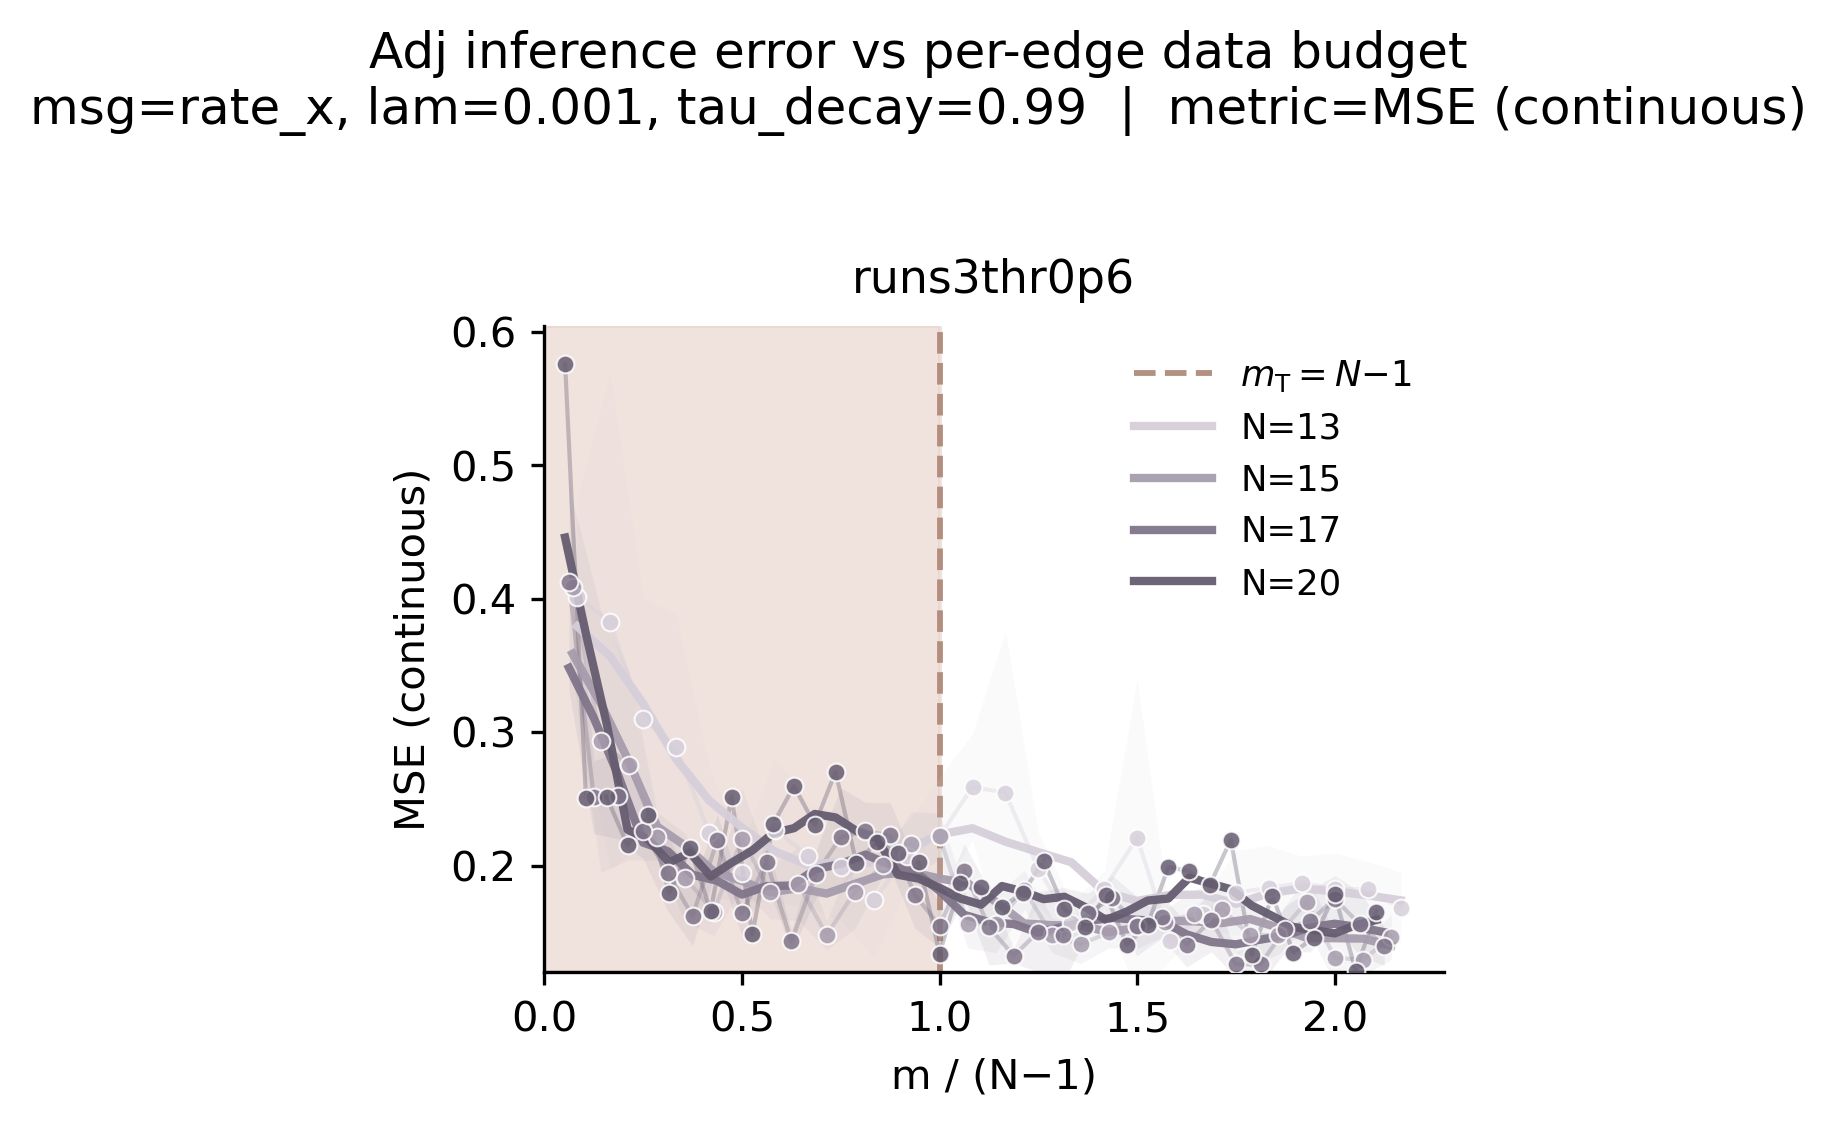

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex

def smooth_y(x, y, window=3):
    """Centered moving average on y (sorted by x), edge-padded."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(y) < 3 or window < 2:
        return x, y
    order = np.argsort(x); x, y = x[order], y[order]
    w = int(window) | 1          # ensure odd
    pad = w // 2
    ys = np.convolve(np.pad(y, (pad, pad), mode='edge'), np.ones(w)/w, mode='valid')
    return x, ys

# ---- colour palette (warm taupe -> sage teal -> slate blue) ----------
# _FIG5_CMAP = LinearSegmentedColormap.from_list("fig5", ["#B08A7A", "#6F8F8D", "#5E6F8E"])
# ---- colour palette (dusty purple family based on #AD81B7) ----------
# _FIG5_CMAP = LinearSegmentedColormap.from_list("fig5_purple", ["#6F4F79", "#AD81B7", "#E2D4E6"])
_FIG5_CMAP = LinearSegmentedColormap.from_list("fig5_purple", ["#D6CFDA", "#8E8297", "#655C70"])

def _node_colors(n_list):
    if len(n_list) <= 1:
        return {n_list[0]: "#6F8F8D"} if n_list else {}
    return {n: to_hex(_FIG5_CMAP(i / (len(n_list)-1))) for i, n in enumerate(n_list)}

# ---- main plot -------------------------------------------------------
def plot_cross_nodes_beautified(pooled, metric=ERROR_METRIC, ncols=None, smooth_window=3):
    label = ERROR_LABELS.get(metric, metric)
    agg   = aggregate_metric(pooled, metric)
    adj_types, n_nodes_list = sorted(agg.adj_type.unique()), sorted(agg.N.unique())
    ncols = ncols or len(adj_types)
    node_color = _node_colors(n_nodes_list)

    fig, axes = plt.subplots(1, ncols, figsize=(3.8*ncols, 3.6), squeeze=False, sharey=True, dpi=300)

    for j, adj in enumerate(adj_types):
        ax = axes[0][j]
        all_y = []

        # shaded region + reference line at m_T = N-1
        ax.axvspan(0, 1, color="#E8D5CD", alpha=0.65, zorder=0)
        ax.axvline(1, color="#B08A7A", lw=1.4, ls="--", alpha=0.95, zorder=1, label=r"$m_\mathrm{T}=N{-}1$")

        for n_val in n_nodes_list:
            s = agg[(agg.adj_type == adj) & (agg.N == n_val)].sort_values("x_per_edge")
            if s.empty or s["mean"].isna().all():
                continue
            x, y = s.x_per_edge.values.astype(float), s["mean"].values.astype(float)
            std  = s["std"].fillna(0).values.astype(float)
            col  = node_color[n_val]
            all_y.extend(y)

            if (s.n_seeds > 1).any():                                               # ±std band
                ax.fill_between(x, y-std, y+std, color=col, alpha=0.10, lw=0, zorder=1)
            ax.plot(x, y, color=col, lw=1.0, alpha=0.35, zorder=2)                  # raw thin
            xs, ys = smooth_y(x, y, window=smooth_window)
            ax.plot(xs, ys, color=col, lw=2.0, alpha=0.95, zorder=3, label=f"N={n_val}")  # smooth
            ax.scatter(x, y, s=18, color=col, edgecolor="white", lw=0.5, alpha=0.85, zorder=4)

        # auto y-range
        if all_y:
            ymin, ymax = np.nanmin(all_y), np.nanmax(all_y)
            ax.set_ylim(ymin*0.99, ymax*1.05)

        # labels & cosmetics
        ax.set_title(adj, fontsize=11, pad=8)
        ax.set_xlabel("m / (N\u22121)")
        if j == 0:
            ax.set_ylabel(label)
        ax.set_xlim(left=0.0)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        for sp in ("left", "bottom"):
            ax.spines[sp].set_linewidth(0.8)
        ax.tick_params(direction="out", length=3.2, width=0.8)
        ax.set_axisbelow(True)
        ax.legend(fontsize=8.5, loc="best", frameon=False, handlelength=2.2)

    msgs_str = ", ".join(sorted(pooled.msg_config.unique()))
    fig.suptitle(
        f"Adj inference error vs per-edge data budget\n"
        f"msg={msgs_str}, lam={LAM_WANT}, tau_decay={TAU_DECAY_WANT}  |  metric={label}",
        fontsize=12, y=1.03)
    fig.tight_layout()
    return fig

fig = plot_cross_nodes_beautified(pooled, metric=ERROR_METRIC, smooth_window=5)
# fig.savefig(os.path.join(STRUC_DIR, 'structure_data_requirement.pdf'),
#             dpi=300, bbox_inches='tight')
plt.show()


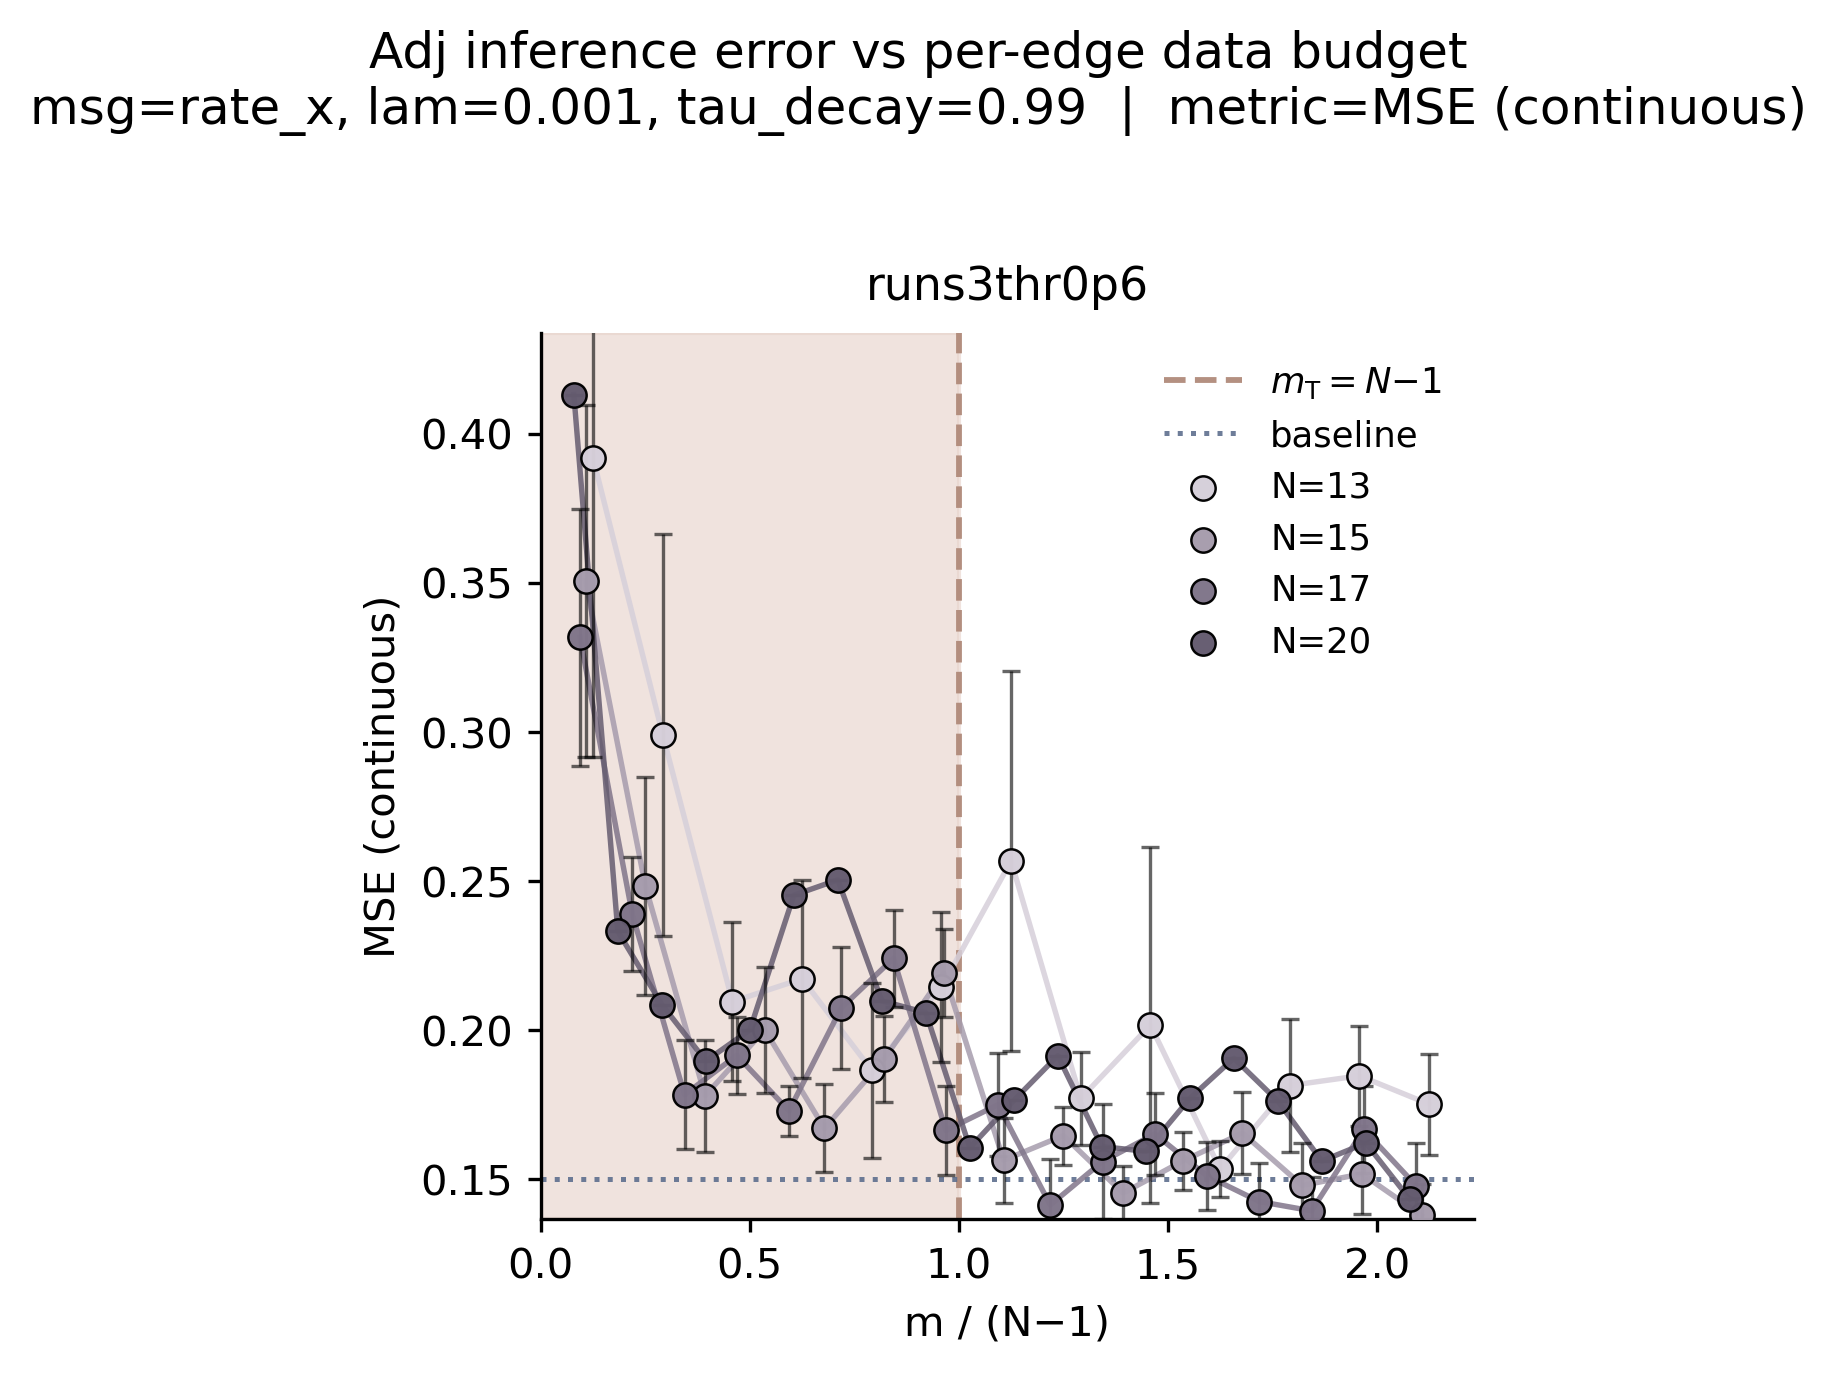

In [8]:
# ---- Scatter + errorbar, pairwise-binned (every 2 points averaged) ----
def pairwise_bin(x, y, yerr):
    """Average consecutive pairs of sorted (x, y, yerr). Odd tail kept as-is."""
    x, y, yerr = np.asarray(x, float), np.asarray(y, float), np.asarray(yerr, float)
    order = np.argsort(x); x, y, yerr = x[order], y[order], yerr[order]
    xb, yb, eb = [], [], []
    i = 0
    while i < len(x) - 1:
        xb.append((x[i] + x[i+1]) / 2)
        yb.append((y[i] + y[i+1]) / 2)
        eb.append(np.sqrt((yerr[i]**2 + yerr[i+1]**2)) / 2)
        i += 2
    if i < len(x):  # odd leftover
        xb.append(x[i]); yb.append(y[i]); eb.append(yerr[i])
    return np.array(xb), np.array(yb), np.array(eb)

def plot_cross_nodes_errorbar(pooled, metric=ERROR_METRIC, ncols=None):
    label = ERROR_LABELS.get(metric, metric)
    agg   = aggregate_metric(pooled, metric)
    adj_types, n_nodes_list = sorted(agg.adj_type.unique()), sorted(agg.N.unique())
    ncols = ncols or len(adj_types)
    node_color = _node_colors(n_nodes_list)

    fig, axes = plt.subplots(1, ncols, figsize=(4.0*ncols, 4.4), squeeze=False, sharey=True, dpi=300)

    for j, adj in enumerate(adj_types):
        ax = axes[0][j]
        all_y = []

        ax.axvspan(0, 1, color="#E8D5CD", alpha=0.65, zorder=0)
        ax.axvline(1, color="#B08A7A", lw=1.4, ls="--", alpha=0.95, zorder=1,
                   label=r"$m_\mathrm{T}=N{-}1$")
        ax.axhline(0.15, color="#5E6F8E", lw=1.2, ls=":", alpha=0.9, zorder=1, label="baseline")

        for n_val in n_nodes_list:
            s = agg[(agg.adj_type == adj) & (agg.N == n_val)].sort_values("x_per_edge")
            if s.empty or s["mean"].isna().all():
                continue
            x   = s.x_per_edge.values.astype(float)
            y   = s["mean"].values.astype(float)
            std = s["std"].fillna(0).values.astype(float)
            col = node_color[n_val]

            xb, yb, eb = pairwise_bin(x, y, std)
            all_y.extend(yb)

            ax.plot(xb, yb, color=col, lw=1.3, alpha=0.85, zorder=2)
            ax.errorbar(xb, yb, yerr=eb, fmt='none', ecolor='black', elinewidth=0.8,
                        capsize=2.2, capthick=0.8, alpha=0.6, zorder=3)
            ax.scatter(xb, yb, s=34, facecolor=col, edgecolor='black', linewidth=0.6,
                       alpha=0.98, label=f"N={n_val}", zorder=4)

        if all_y:
            ymin, ymax = np.nanmin(all_y), np.nanmax(all_y)
            ax.set_ylim(ymin*0.99, ymax*1.05)

        ax.set_title(adj, fontsize=11, pad=8)
        ax.set_xlabel("m / (N\u22121)")
        if j == 0:
            ax.set_ylabel(label)
        ax.set_xlim(left=0.0)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        for sp in ("left", "bottom"):
            ax.spines[sp].set_linewidth(0.8)
        ax.tick_params(direction="out", length=3.2, width=0.8)
        ax.set_axisbelow(True)
        ax.legend(fontsize=8.5, loc="best", frameon=False, handlelength=2.2)

    msgs_str = ", ".join(sorted(pooled.msg_config.unique()))
    fig.suptitle(
        f"Adj inference error vs per-edge data budget\n"
        f"msg={msgs_str}, lam={LAM_WANT}, tau_decay={TAU_DECAY_WANT}  |  metric={label}",
        fontsize=12, y=1.03)
    fig.tight_layout()
    return fig

fig = plot_cross_nodes_errorbar(pooled, metric=ERROR_METRIC)
# fig.savefig(os.path.join(STRUC_DIR, 'structure_data_requirement_errorbar.pdf'),
#             dpi=300, bbox_inches='tight')
plt.show()
